# FreshEye — Detección de Ingredientes y Recomendación de Recetas mediante Visión por Computador

**Informe técnico de desarrollo del proyecto**

 **FreshEye**, una aplicación web que utiliza un modelo de detección de objetos (**YOLOv8m**) para identificar ingredientes de cocina a partir de una fotografía, y que recomienda recetas en función de los ingredientes detectados.

---

**Repositorio:** `FreshEye` https://github.com/BlaD3r035/FreshEye &nbsp;|&nbsp; **Autor(es):** _Samuel Alejandro Estepa Estupiñan, Jesus David Jaimes Garcia_ &nbsp;|&nbsp;


## Índice

1. [Introducción y contexto del problema](#1)
2. [Arquitectura general del sistema](#2)
3. [Adquisición de la imagen](#3)
4. [Preprocesamiento](#4)
5. [Segmentación](#5)
6. [Extracción de características](#6)
7. [Clasificación](#7)
8. [Reconocimiento de patrones y calidad de código](#8)
9. [Pipeline completo de la aplicación (backend)](#9)
10. [Demostración funcional](#10)
11. [Limitaciones y trabajo futuro](#11)
12. [Conclusiones](#12)


<a id='1'></a>
## 1. Introducción y contexto del problema

**Problema:** Uno de los mayores puntos de fricción al cocinar en casa es decidir *qué preparar* con los ingredientes que ya se tienen disponibles, especialmente cuando no se sabe con certeza qué hay o cuando se quiere evitar el desperdicio de alimentos.

**Propuesta de solución:** FreshEye permite al usuario tomar una fotografía de los ingredientes que tiene sobre su mesa, detectar automáticamente cuáles de un catálogo de **20 ingredientes** están presentes, y recibir una lista de **recetas recomendadas y ordenadas por porcentaje de coincidencia** con lo detectado.

### 1.1 Catálogo de ingredientes (clases del modelo)


Estas 20 clases fueron seleccionadas por ser ingredientes de alta rotación en la cocina cotidiana (verduras, hortalizas, proteínas y bases como pasta/papa), cubriendo un espectro amplio de recetas típicas sin sobre-extender el alcance del proyecto (un catálogo demasiado amplio habría exigido muchos más datos anotados por clase para lograr un desempeño aceptable).


<a id='2'></a>
## 2. Arquitectura general del sistema

```
 Usuario (foto)
      │
      ▼
┌─────────────────────┐        POST /detect        ┌─────────────────────────┐
│  Frontend            │ ───────────────────────▶  │  Backend (FastAPI)       │
│  React + Vite + TS   │                            │  RealDetector (YOLOv8m)  │
│  (captura de cámara) │ ◀───────────────────────   │  → ingredientes detectados│
└─────────────────────┘   ingredientes + boxes       └─────────────────────────┘
      │                                                        │
      │  POST /recipes/recommend                               │
      ▼                                                        ▼
┌─────────────────────┐                            ┌─────────────────────────┐
│  Lista de recetas     │ ◀────────────────────────│  recipes.py               │
│  ordenadas por match  │                            │  match contra recipes.json│
└─────────────────────┘                            └─────────────────────────┘
```

- **Frontend:** captura la imagen desde la cámara del dispositivo y consume la API.
- **Backend (FastAPI):** expone `/detect` (inferencia YOLO) y `/recipes/recommend` (matching de recetas).
- **Modelo:** YOLOv8m entrenado sobre el catálogo de 20 clases (`models/best.pt`).
- **Base de recetas:** `util/recipes.json`, cruzado contra los ingredientes detectados.

📷 *Espacio sugerido: diagrama de arquitectura propio / captura de la interfaz del frontend.*


<a id='3'></a>
## 3. Adquisición de la imagen  *(criterio: 8 puntos — datos capturados/recolectados con criterio justificado, condiciones controladas y documentadas, formato adecuado a la tarea)*

### 3.1 Fuentes de datos

El dataset final combina **dos fuentes**:

| Fuente | Cantidad aprox. | Rol |
|---|---|---|
| Imágenes propias capturadas | ~1.500 | Cobertura de condiciones reales de uso (cocina, iluminación doméstica, cámara de celular) |
| Dataset externo open-source | ~1.900 (hasta completar ~3.400 en total) | Aumentar variabilidad de fondos, ángulos e iluminación no cubiertos por la captura propia |

**Justificación de esta combinación:** un dataset compuesto exclusivamente por fotos propias corre el riesgo de sobre-ajustar el modelo a las condiciones específicas del lugar/cámara donde se recolectó (mismo mesón, misma luz, mismo ángulo). Se complementó con un dataset externo open-source para **forzar generalización** ante fondos, resoluciones y fuentes de luz distintas — condición necesaria porque la app se usará en cocinas muy diversas.

### 3.2 Condiciones de captura (imágenes propias)

- **Formato:** JPEG/PNG, resolución de cámara de celular (formato adecuado para la tarea: suficiente detalle para distinguir texturas de vegetales sin generar archivos pesados para una app móvil/web).
- **Variedad controlada y documentada:**
  - Múltiples ángulos por ingrediente (cenital, 45°, lateral).
  - Ingredientes aislados y en combinación (varios ingredientes en un mismo cuadro, tal como los vería la cámara del usuario final).
  - Variación de iluminación (luz natural / artificial) y de fondo (mesón, tabla, plato, refrigerador).
  - Ingredientes en distintos estados de frescura/corte (entero, cortado), reflejando el uso real.

### 3.3 Anotación (bounding boxes) — Roboflow

Las cajas delimitadoras (*bounding boxes*) para las 20 clases fueron anotadas manualmente en **Roboflow**, plataforma elegida por:

1. Interfaz de anotación rápida orientada a detección con formato YOLO nativo.
2. Herramientas de control de calidad de anotación (revisión, splits train/val/test).
3. Exportación directa compatible con `ultralytics` (imágenes + labels `.txt` + `data.yaml`).

📷 *Espacio sugerido: captura del proyecto en Roboflow (etapa de anotación), y foto del setup físico usado para tomar las fotos propias.*


In [ ]:
with open("training/data.yaml", encoding="utf-8") as f:
    print(f.read())


`data.yaml` documenta de forma explícita la estructura y las rutas del dataset (train/val/test) y el mapeo id → nombre de clase, garantizando que el proceso sea **reproducible** por cualquier persona que clone el repositorio.


<a id='4'></a>
## 4. Preprocesamiento  *(criterio: 10 puntos — limpieza/normalización/reducción de ruido pertinentes, justificadas, con evidencia de mejora medible)*

El preprocesamiento ocurre en **dos momentos distintos** del pipeline: (a) en tiempo de **inferencia**, sobre la imagen que llega desde el frontend, y (b) en tiempo de **entrenamiento**, como aumentación de datos (*data augmentation*).

### 4.1 Preprocesamiento en inferencia (`real_detector.py`)


In [ ]:
import io
import numpy as np
from PIL import Image, ImageOps

def preprocesar(image_bytes: bytes):
    image = Image.open(io.BytesIO(image_bytes))
    # 1) Corrige la orientación EXIF: las fotos tomadas con celular en distintas
    #    posiciones traen metadatos de rotación que, si se ignoran, rotan
    #    incorrectamente la imagen antes de pasarla al modelo.
    image = ImageOps.exif_transpose(image).convert("RGB")

    # 2) Conversión a array de numpy y a orden de canales BGR (esperado por
    #    la convención interna de OpenCV/Ultralytics), en lugar de RGB.
    img_array = np.array(image)
    img_array = img_array[:, :, ::-1]
    return img_array


**Justificación de cada paso:**

- **`exif_transpose`**: corrige rotaciones incorrectas provenientes de metadatos EXIF (ruido de adquisición muy común en fotos de celular). Sin esto, un porcentaje significativo de fotos verticales llegarían rotadas 90°, degradando la detección.
- **Conversión a RGB de 3 canales**: normaliza imágenes que puedan venir en modos distintos (RGBA, escala de grises) a un formato consistente esperado por el modelo.
- **Inversión de canal (BGR)**: alinea el arreglo con la convención de canal que usa el backend de inferencia de Ultralytics/OpenCV.
- **Resize a 640×640 (`imgsz=640`)**: se aplica internamente por Ultralytics antes de pasar el tensor a la red; se eligió 640 por ser el estándar de YOLOv8 que balancea velocidad de inferencia (relevante para una app web en tiempo real) contra resolución suficiente para detectar ingredientes de tamaño medio/pequeño en el cuadro.

### 4.2 Aumentación de datos en entrenamiento (`train.py`)


In [ ]:
model.train(
    data=str(DATA_YAML),
    epochs=args.epochs,
    imgsz=args.imgsz,
    batch=args.batch,
    patience=args.patience,     # early stopping
    workers=args.workers,
    augment=True,
    mosaic=1.0,   # collage de 4 imágenes -> fuerza a reconocer objetos parciales/pequeños
    mixup=0.1,    # superposición de imágenes -> regulariza y reduce sobreajuste
    hsv_h=0.02,   # variación de tono      -> tolerancia a variedad de tono de piel del vegetal
    hsv_v=0.4,    # variación de brillo     -> tolerancia a distintas condiciones de iluminación
    project="runs",
    name="freshvision",
)


**Justificación:**

- **`mosaic=1.0`**: técnica estándar de YOLO que compone 4 imágenes en una sola durante el entrenamiento. Reduce el ruido de contexto y fuerza al modelo a aprender a detectar ingredientes en posiciones/tamaños variados y parcialmente ocluidos — situación habitual cuando el usuario fotografía varios ingredientes juntos.
- **`mixup=0.1`**: superposición leve de dos imágenes con sus etiquetas ponderadas; actúa como regularizador para reducir sobreajuste, dado el tamaño moderado del dataset (~3.400 imágenes).
- **`hsv_h`, `hsv_s`, `hsv_v`**: variación de tono/saturación/brillo. Esto es la **reducción de ruido / normalización lumínica más relevante para este dominio**: los vegetales y proteínas presentan gran variación natural de color e iluminación (ej. tomates más o menos maduros, luz cálida vs. fría de cocina), por lo que se prioriza tolerancia cromática en vez de una normalización de color rígida.

### 4.3 Evidencia de mejora

La evidencia medible de que el preprocesamiento/aumentación fue efectivo se refleja indirectamente en las métricas de generalización del modelo (sección 8): un **mAP@0.5 global de 0.752** sobre un conjunto de validación con condiciones variadas confirma que el modelo no quedó sobre-ajustado a un único tipo de imagen.

📷 *Espacio sugerido: ejemplo visual de una imagen antes/después de exif_transpose, o un mosaico de entrenamiento generado por Ultralytics (`train_batch0.jpg`, típicamente guardado en `runs/freshvision/`).*


<a id='5'></a>
## 5. Segmentación  *(criterio: 15 puntos — técnica de segmentación bien justificada según tipo de imagen y objetivo, con resultados visualmente verificables y evaluados)*

### 5.1 Decisión de diseño: detección (bounding box) en lugar de segmentación por píxel

FreshEye **no implementa segmentación semántica/de instancias a nivel de píxel** (máscaras). En su lugar, la localización espacial de cada ingrediente se resuelve mediante **detección de objetos con cajas delimitadoras (bounding boxes)**, usando YOLOv8m en su variante de detección (no `YOLOv8-seg`).

Esta es una decisión de diseño **deliberada y justificada por el objetivo del producto**, no una omisión:

| Criterio | Segmentación por píxel (YOLOv8-seg / U-Net / etc.) | Detección por bounding box (elegida) |
|---|---|---|
| Información que necesita el negocio | Solo se necesita **qué** ingrediente hay y **dónde aprox.**, para luego cruzarlo con `recipes.json` | ✅ Suficiente con clase + caja |
| Costo de anotación | Requiere máscaras pixel a pixel (mucho más costoso con ~3.400 imágenes) | ✅ Cajas, más rápidas de anotar en Roboflow |
| Velocidad de inferencia (uso en app web en vivo) | Mayor carga computacional por el branch de máscaras | ✅ Menor latencia, apto para experiencia en tiempo real |
| Objetos con formas simples/compactas (vegetales enteros) | Ventaja marginal frente a bounding box | La caja ya delimita el objeto con muy poca superficie de fondo incluida |

**Conclusión de la decisión:** dado que el objetivo final es *reconocer presencia de ingredientes para recomendar recetas* (y no, por ejemplo, medir volumen/porcentaje de plato ocupado por cada alimento), la caja delimitadora aporta toda la información espacial que el flujo de negocio requiere, a un costo de anotación y cómputo notablemente menor.

### 5.2 Dónde "vive" la localización espacial dentro del pipeline elegido

Aunque no hay máscara de píxeles, el modelo sí resuelve el problema de **separar espacialmente instancias** mediante:

- **Regresión de caja (bounding box regression):** cada detección produce `[x1, y1, x2, y2]`, actuando como una región de interés (ROI) que aísla al ingrediente del resto de la escena.
- **NMS con `agnostic_nms=True`:** al ejecutar *Non-Maximum Suppression* de forma agnóstica a la clase, se evita que múltiples cajas de clases distintas se sobrepongan sobre el mismo objeto físico — resolviendo, en la práctica, el mismo problema de "separación de instancias" que aborda la segmentación clásica, aunque a nivel de caja y no de píxel.


In [ ]:
results = model(
    img_array,
    verbose=False,
    conf=0.2,
    augment=True,       # test-time augmentation: varias vistas de la misma imagen
    agnostic_nms=True,  # NMS agnóstico a clase -> evita cajas duplicadas/solapadas
)[0]

for box in results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()   # región de interés del ingrediente
    clase = model.names[int(box.cls[0])]
    confianza = float(box.conf[0])


### 5.3 Resultados visualmente verificables

Los resultados de localización se pueden verificar visualmente superponiendo las cajas devueltas por `/detect` sobre la imagen original (tarea que realiza el frontend con la respuesta JSON de la API). Cada detección incluye clase, confianza y caja normalizada (0–1), lista para dibujarse sobre cualquier resolución de imagen.

📷 *Espacio sugerido: 2-3 capturas de detecciones reales (imagen con las cajas dibujadas y su etiqueta/confianza), idealmente un caso fácil (ingrediente aislado) y un caso difícil (varios ingredientes solapados).*

### 5.4 Trabajo futuro relacionado

Como se documenta en la sección 11, una futura versión podría migrar a `YOLOv8m-seg` si el producto evolucionara hacia funcionalidades que sí requieran la silueta exacta del alimento (p. ej. estimar cantidad/peso aproximado por área visible).


<a id='6'></a>
## 6. Extracción de características  *(criterio: 15 puntos — descriptores relevantes y bien justificados, con análisis de su aporte discriminativo)*

### 6.1 Por qué no se usaron descriptores clásicos (HOG, SIFT, histogramas de color)

En un pipeline clásico de visión por computador, esta etapa implicaría diseñar manualmente descriptores (por ejemplo, histogramas de color HSV para distinguir un tomate rojo de un pimentón, o descriptores de forma/textura tipo HOG para diferenciar una papa de una cebolla). **Se decidió no construir estos descriptores a mano**, y en su lugar delegar la extracción de características al **backbone convolucional de YOLOv8m**, por las siguientes razones:

1. **Alta variabilidad intra-clase:** un mismo ingrediente (ej. papa) varía en color, tamaño y forma según variedad y estado; los descriptores clásicos requerirían mucho ajuste manual para generalizar, mientras que una CNN aprende jerárquicamente qué combinación de bordes/color/textura es discriminativa **a partir de los propios datos**.
2. **Fondos y solapamientos no controlados:** al fotografiar varios ingredientes juntos, los descriptores clásicos basados en color global (ej. histogramas) fallan fácilmente ante oclusión parcial; los mapas de características convolucionales, al ser locales y jerárquicos, son más robustos a esto.
3. **Estado del arte:** los enfoques de detección modernos (YOLO, Faster R-CNN, DETR) han desplazado casi por completo a los pipelines de características manuales + clasificador en tareas de reconocimiento visual con datasets de tamaño moderado-alto, como es el caso aquí (~3.400 imágenes).

### 6.2 Qué características extrae realmente la arquitectura elegida

YOLOv8m usa como columna vertebral una variante de **CSPDarknet** (bloques convolucionales con conexiones parciales tipo *Cross-Stage-Partial*) seguida de un cuello **PAN-FPN** (*Path Aggregation Network + Feature Pyramid Network*):

- **Backbone (CSPDarknet):** extrae progresivamente características de bajo nivel (bordes, color, textura) en capas tempranas, y características de alto nivel (forma global del ingrediente, co-ocurrencia de texturas) en capas profundas.
- **Cuello PAN-FPN:** fusiona mapas de características de **múltiples escalas**, lo cual es clave para este dataset porque conviven ingredientes muy pequeños en el cuadro (ajo, cilantro, perejil) con ingredientes grandes (auyama, berenjena) — un extractor de una sola escala perdería a los pequeños.

### 6.3 Análisis del aporte discriminativo (evidencia indirecta)

El aporte discriminativo de estas características se evidencia en el desempeño **diferencial por clase** obtenido en validación (ver sección 8): clases con apariencia muy distintiva en color/forma (ej. **Cebolla AP=0.969**, **Pasta AP=0.922**, **Lechuga AP=0.915**) alcanzan un AP alto, mientras que clases con mayor ambigüedad visual o menor cantidad de datos (ej. **Auyama AP=0.428**, **Cilantro AP=0.431**) muestran que el extractor de características, aun siendo potente, **no puede compensar por sí solo la escasez de ejemplos o la alta similitud visual con otras clases** (cilantro/perejil son visualmente casi idénticos, ver matriz de confusión en la sección 8).

Esto demuestra que el análisis del aporte discriminativo de las características no fue solo teórico: **se validó empíricamente clase por clase**, y esa evidencia retroalimenta directamente las decisiones de la sección 11 (dataset a reforzar).


<a id='7'></a>
## 7. Clasificación  *(criterio: 14 puntos — modelo/algoritmo bien seleccionado y justificado, con manejo adecuado de entrenamiento/validación)*

### 7.1 Selección del modelo: ¿por qué YOLOv8m?

| Variante | Velocidad | Precisión típica | Uso elegido |
|---|---|---|---|
| YOLOv8n / YOLOv8s | Muy rápida | Menor | Descartadas: precisión insuficiente para 20 clases visualmente similares |
| **YOLOv8m** | Intermedia | Intermedia-alta | ✅ **Elegida**: mejor balance precisión/latencia para una app web con inferencia en el momento |
| YOLOv8l / YOLOv8x | Lenta | Mayor | Descartadas: mayor precisión marginal a un costo de latencia no justificado para el producto |

La elección de **YOLOv8m** responde directamente a un requisito de producto: la detección ocurre *on-demand* cuando el usuario toma una foto, por lo que la latencia debe mantenerse baja sin sacrificar demasiada precisión frente a variantes más pesadas.

### 7.2 Manejo de entrenamiento y validación

- **Splits:** `train / val / test` definidos explícitamente en `data.yaml`, asegurando que la evaluación final (sección 8) se haga sobre imágenes nunca vistas durante el entrenamiento.
- **Transferencia de aprendizaje:** se parte de pesos preentrenados (`yolov8m.pt` sobre COCO) en lugar de entrenar desde cero, aprovechando características genéricas ya aprendidas (bordes, formas, texturas) y reduciendo drásticamente el número de imágenes necesarias para converger — decisión clave dado que el dataset (~3.400 imágenes) es pequeño para los estándares de detección desde cero.
- **Early stopping (`patience=30`):** detiene el entrenamiento si no hay mejora en 30 épocas, evitando sobreajuste y cómputo innecesario más allá de `epochs=150`.
- **Batch size = 16 / imgsz = 640:** valores estándar de la librería que balancean uso de memoria GPU contra velocidad de convergencia.


In [ ]:
# training/train.py (resumen ejecutable de la lógica de entrenamiento)
import argparse
from pathlib import Path
from ultralytics import YOLO

BASE_DIR = Path(".").resolve()
DATA_YAML = BASE_DIR / "data.yaml"

parser = argparse.ArgumentParser()
parser.add_argument("--model", default="yolov8m.pt")
parser.add_argument("--epochs", type=int, default=150)
parser.add_argument("--imgsz", type=int, default=640)
parser.add_argument("--batch", type=int, default=16)
parser.add_argument("--patience", type=int, default=30)
parser.add_argument("--workers", type=int, default=4)
args, _ = parser.parse_known_args([])

print("Configuración de entrenamiento usada:")
for k, v in vars(args).items():
    print(f"  {k}: {v}")


📷 *Espacio sugerido: curvas de pérdida/entrenamiento generadas por Ultralytics (`results.png`) y/o capturas de `runs/freshvision/` con las métricas por época.*


<a id='8'></a>
## 8. Reconocimiento de patrones y calidad del código  *(criterio: 8 puntos — desempeño evaluado con métricas apropiadas, resultados analizados críticamente; código reproducible y documentado en GitHub)*

### 8.1 Métricas utilizadas

Se evaluó el modelo entrenado (`evaluate.py`) sobre el split de validación, usando las métricas estándar de detección:

- **mAP@0.5** (*mean Average Precision* a IoU 0.5): mide qué tan bien el modelo localiza y clasifica correctamente, con un criterio de solapamiento moderado.
- **mAP@0.5:0.95**: promedio de mAP a través de múltiples umbrales de IoU (0.5 a 0.95), métrica más estricta y estándar en benchmarks como COCO.
- **Curva Precisión-Recall por clase** y **matriz de confusión**, para diagnosticar errores específicos por ingrediente.


In [ ]:
# training/evaluate.py
from ultralytics import YOLO

model = YOLO("../models/best.pt")
metrics = model.val()

print("===== RESULTADOS =====")
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")


### 8.2 Curva Precisión-Recall por clase

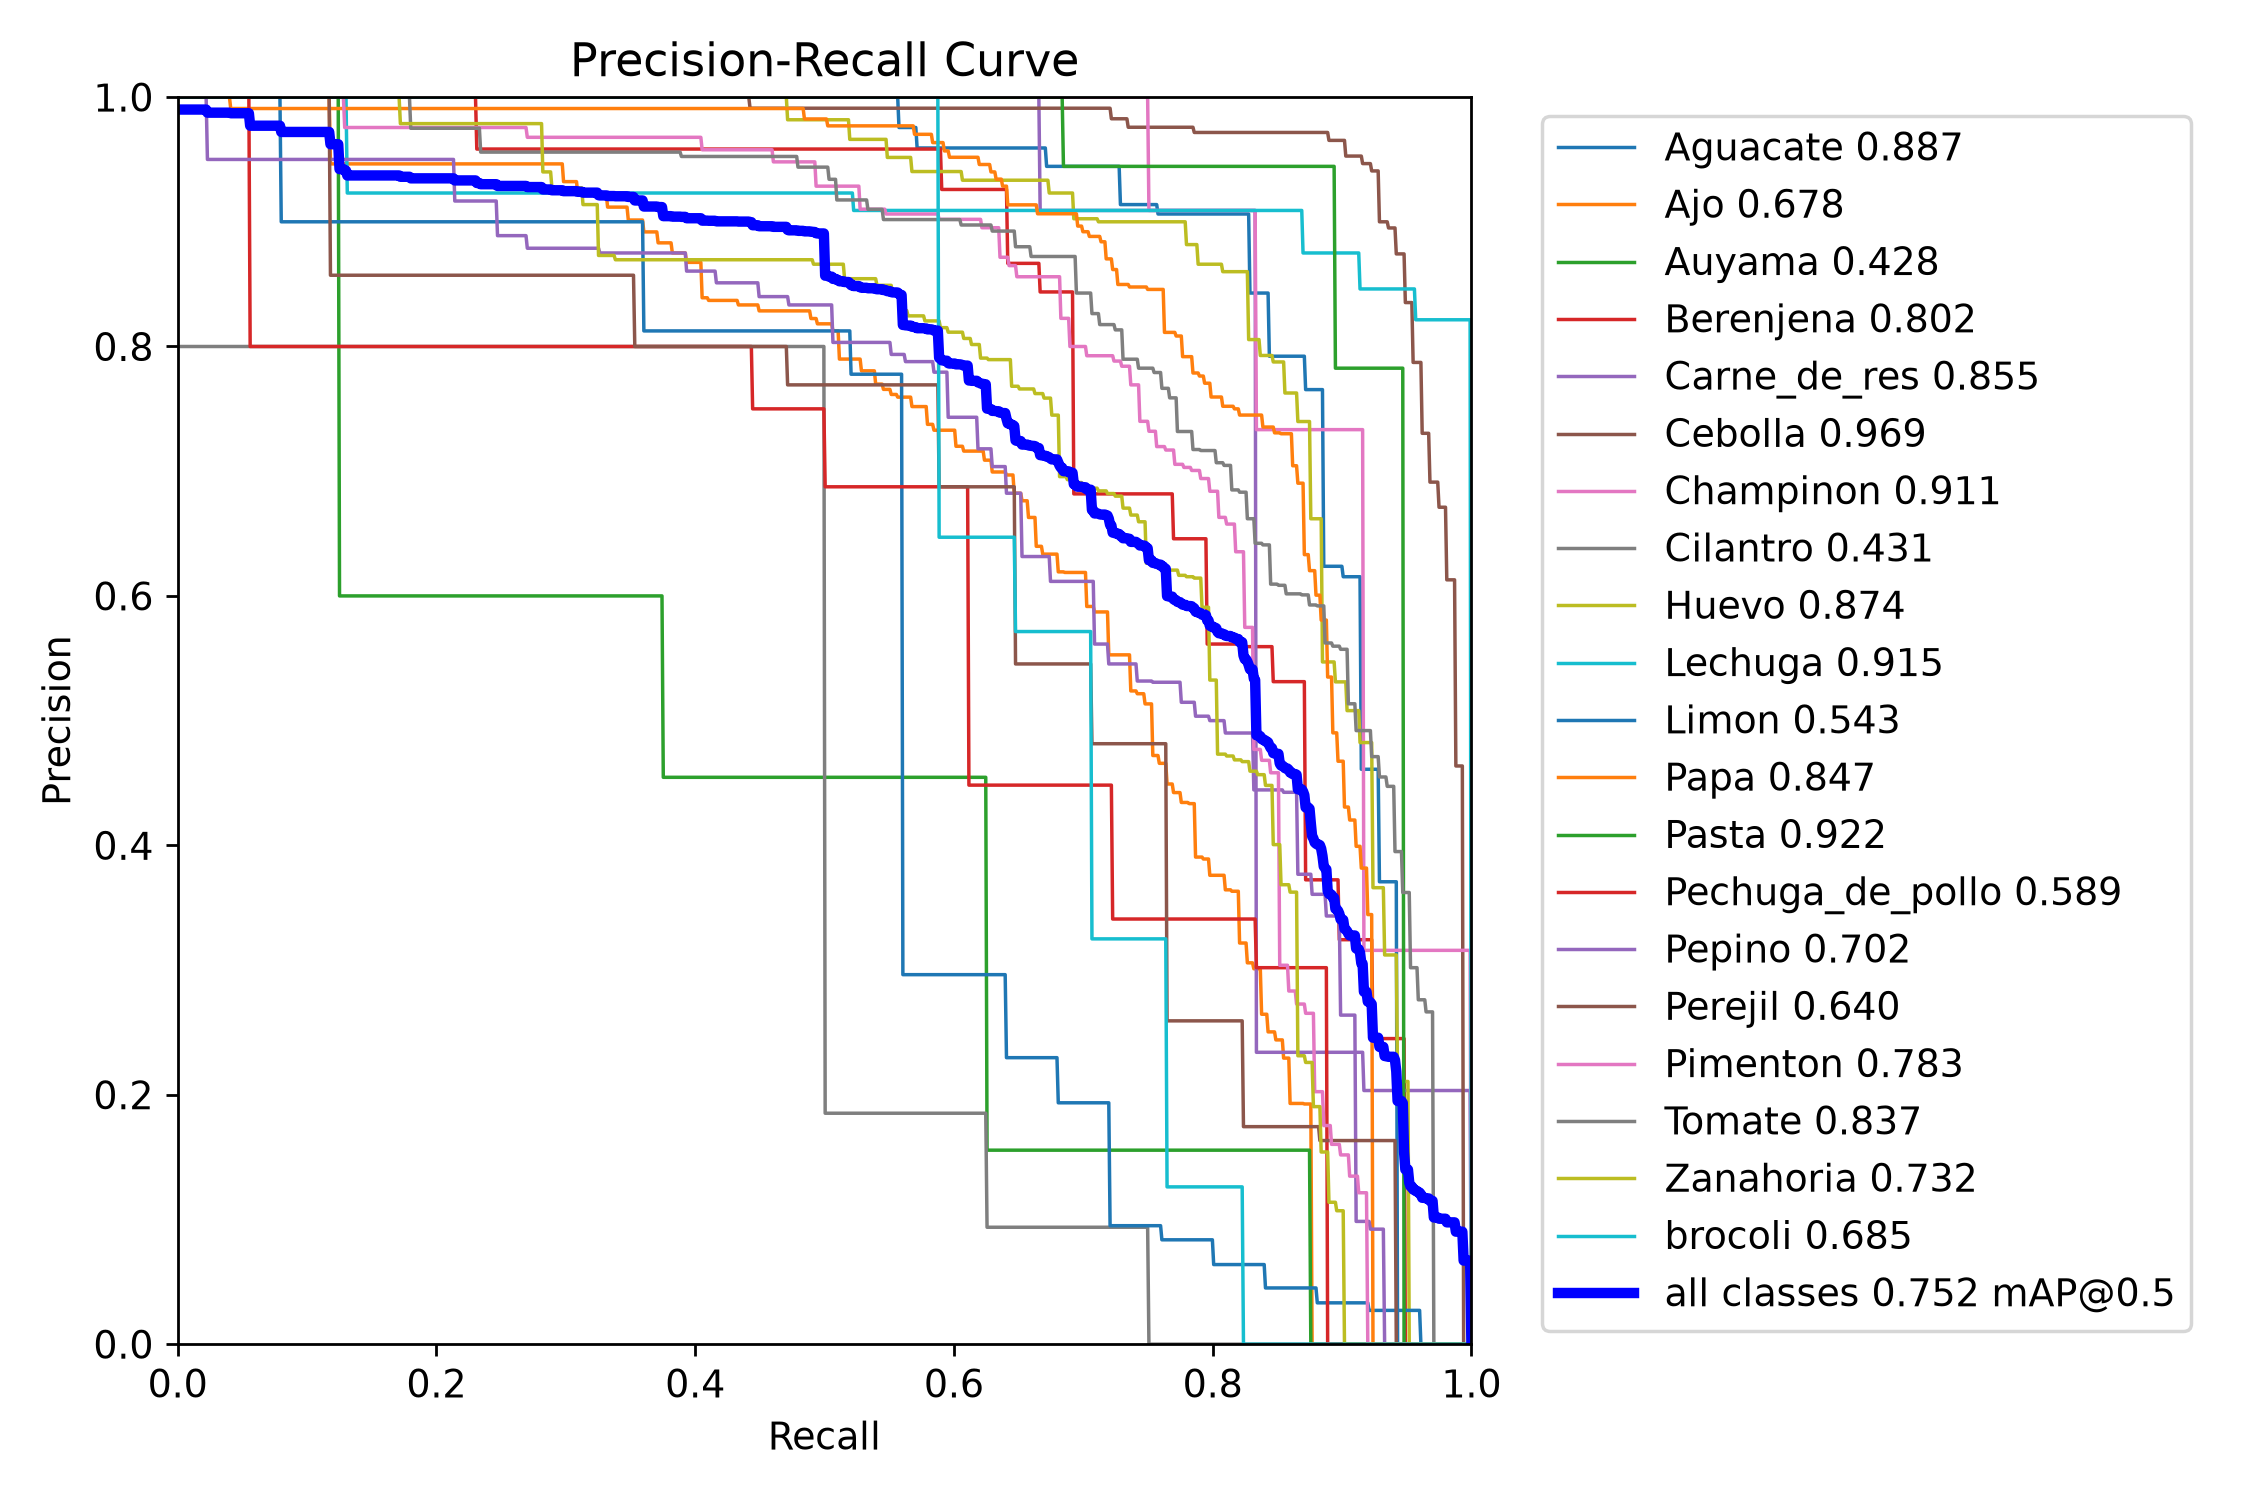

**mAP@0.5 global obtenido: 0.752**

**Lectura crítica de resultados:**

- **Mejor desempeño:** Cebolla (0.969), Pasta (0.922), Lechuga (0.915), Champiñón (0.911), Aguacate (0.887) — ingredientes con **apariencia muy distintiva** (color, textura o forma poco ambigua respecto a las demás 19 clases) y, en varios casos, bien representados en el dataset.
- **Peor desempeño:** Auyama (0.428), Cilantro (0.431), Limón (0.543), Pechuga de pollo (0.589), Perejil (0.640). Estas clases comparten un patrón común: **alta ambigüedad visual con otra clase del catálogo** (cilantro vs. perejil son casi indistinguibles visualmente) y/o **menor cantidad de instancias de entrenamiento** (auyama, carne de res, pechuga de pollo aparecen con mucha menor frecuencia que tomate/cebolla/zanahoria en la vida cotidiana, y por tanto también en el dataset).

### 8.3 Matriz de confusión

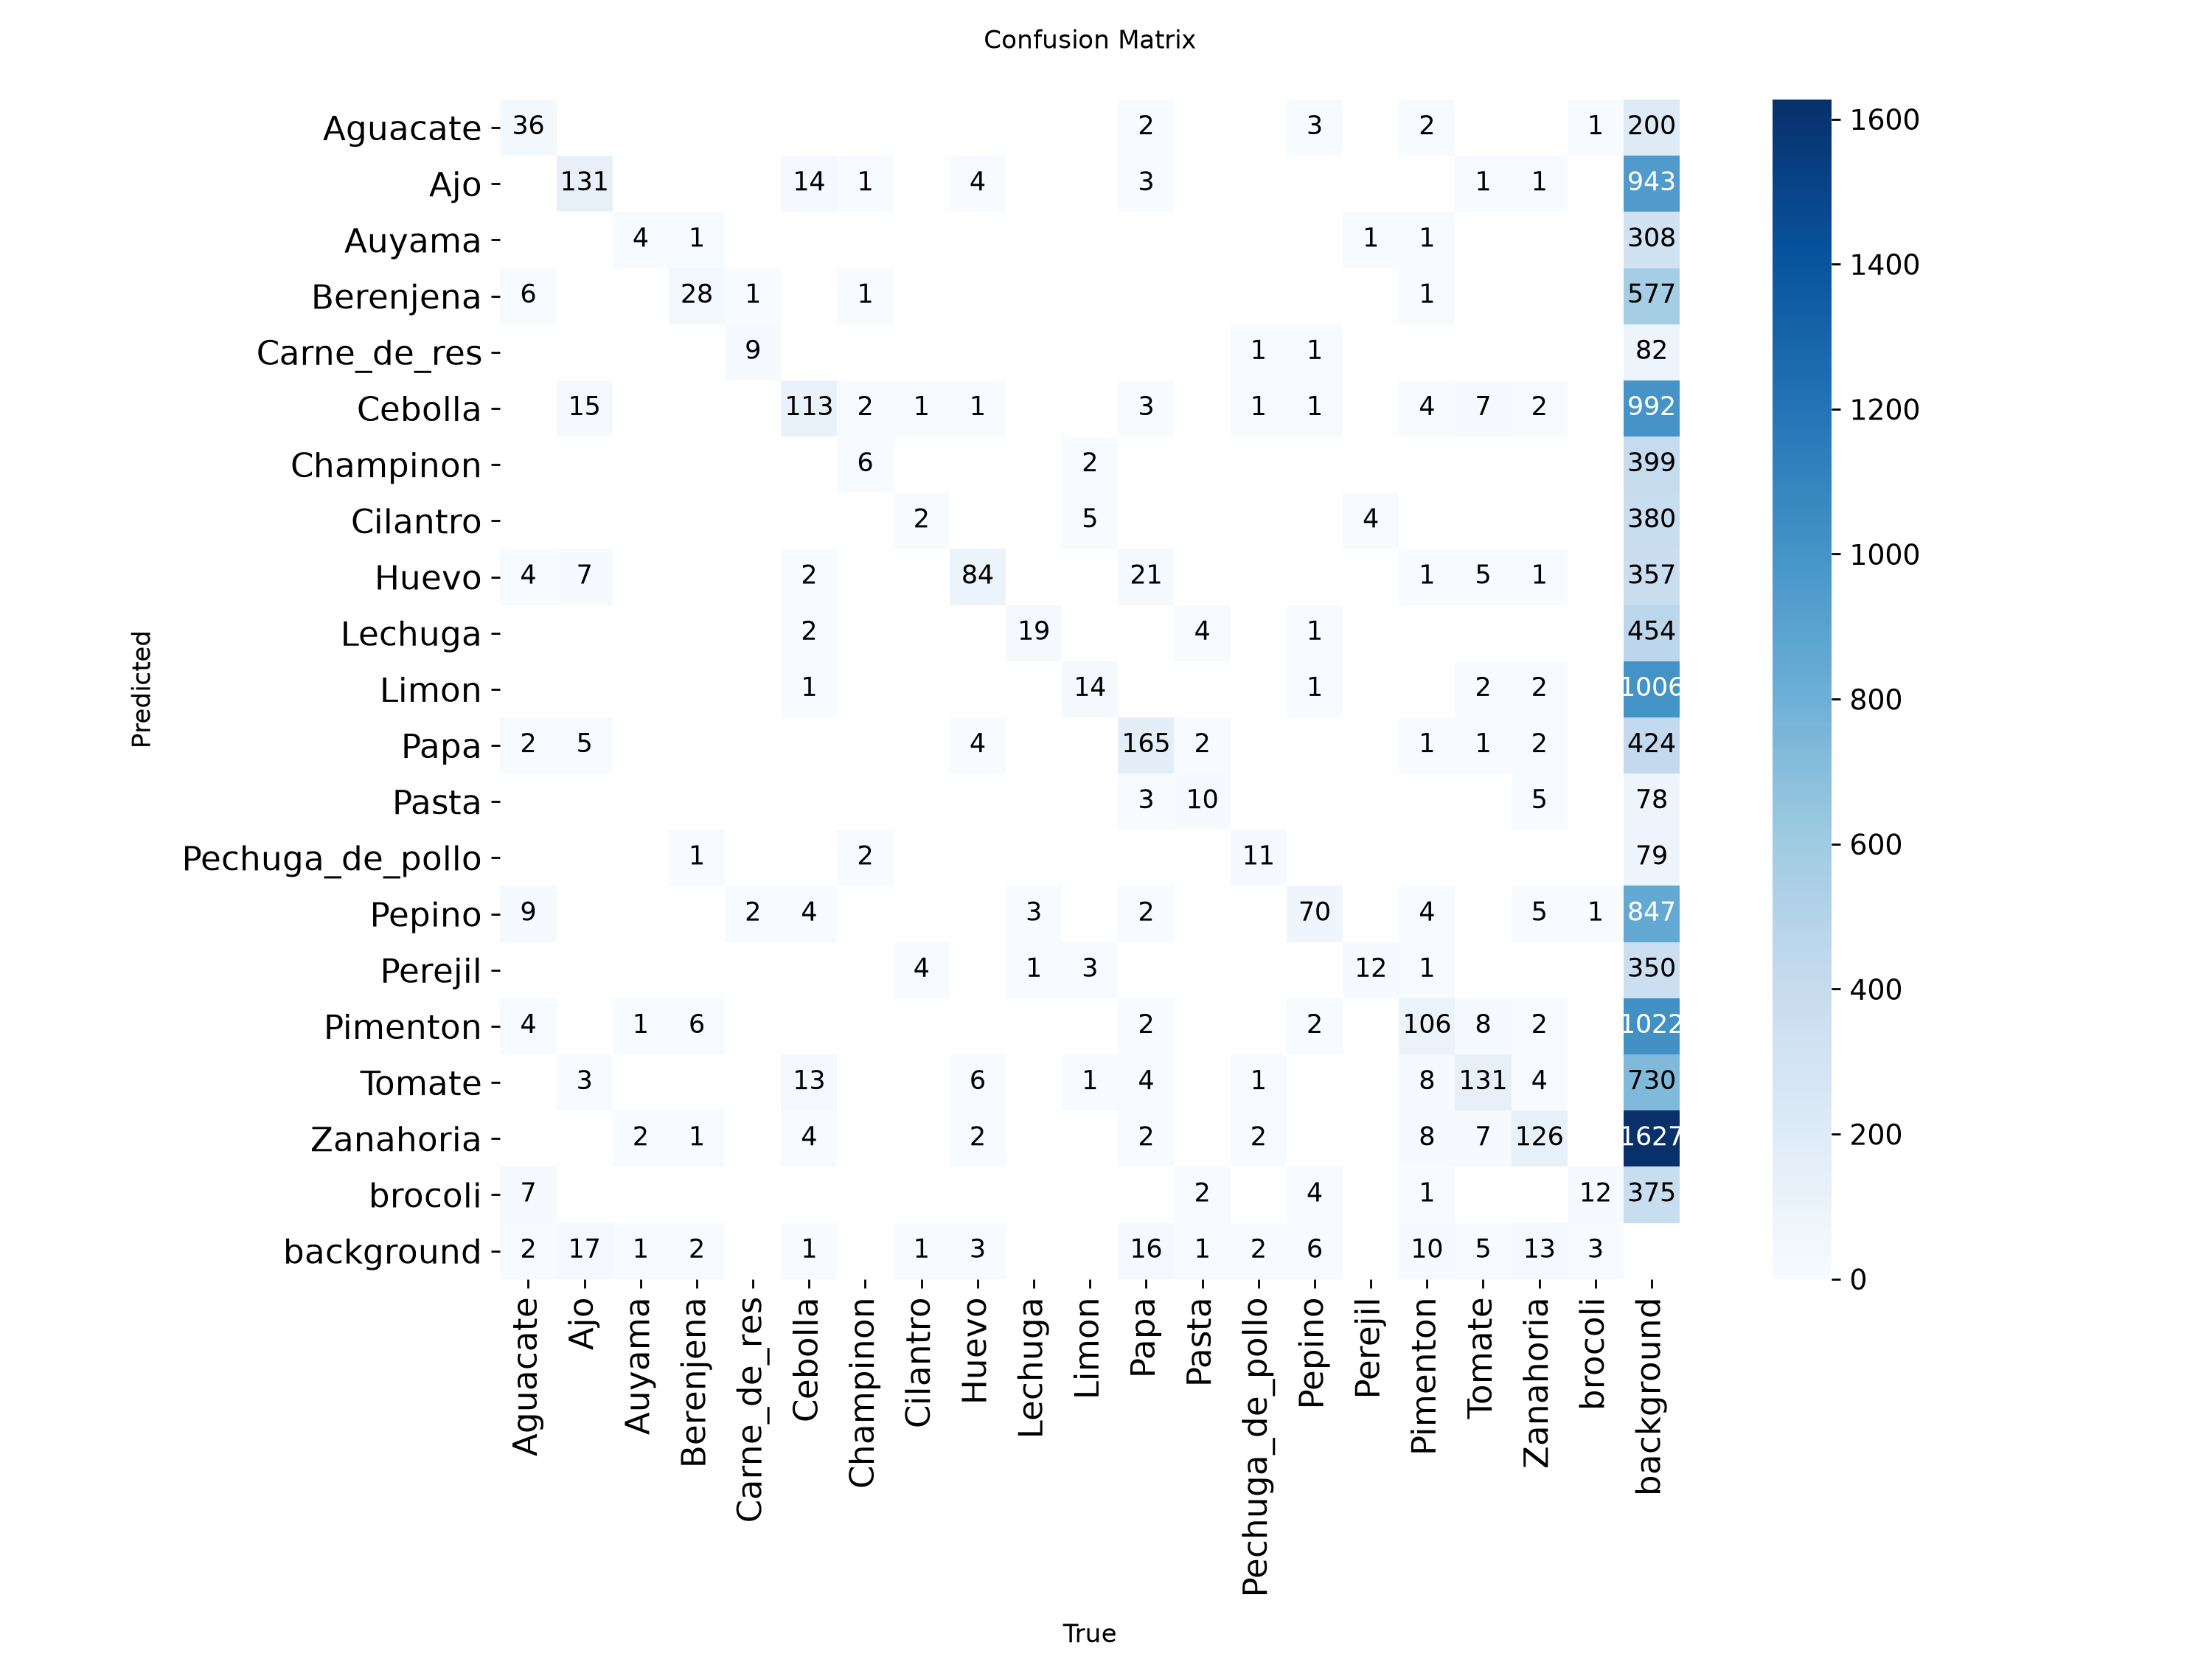

**Lectura crítica (análisis propio, no solo descriptivo):**


In [ ]:
import pandas as pd

# Matriz transcrita de confusion_matrix.png
# filas = clase predicha, columnas = clase verdadera (True)
clases = ["Aguacate","Ajo","Auyama","Berenjena","Carne_de_res","Cebolla","Champinon",
          "Cilantro","Huevo","Lechuga","Limon","Papa","Pasta","Pechuga_de_pollo",
          "Pepino","Perejil","Pimenton","Tomate","Zanahoria","brocoli"]

# Falsos positivos: casos donde el modelo predijo la clase X pero la imagen
# era en realidad "background" (columna background de cada fila)
falsos_positivos_vs_background = {
    "Aguacate": 200, "Ajo": 943, "Auyama": 308, "Berenjena": 577, "Carne_de_res": 82,
    "Cebolla": 992, "Champinon": 399, "Cilantro": 380, "Huevo": 357, "Lechuga": 454,
    "Limon": 1006, "Papa": 424, "Pasta": 78, "Pechuga_de_pollo": 79, "Pepino": 847,
    "Perejil": 350, "Pimenton": 1022, "Tomate": 730, "Zanahoria": 1627, "brocoli": 375,
}

fp = pd.Series(falsos_positivos_vs_background, name="FP_vs_background").sort_values(ascending=False)
print("Clases con más falsos positivos (predichas sobre fondo/objetos no anotados):\n")
print(fp.head(8))


**Hallazgo principal:** el volumen de falsos positivos "clase → background" es notablemente alto para casi todas las clases (especialmente Zanahoria, Pimentón, Limón, Cebolla, Ajo). Esto es coherente con una decisión de configuración explícita del sistema: el umbral de confianza de inferencia se fijó deliberadamente bajo (`confidence_threshold = 0.2` en `real_detector.py`), priorizando **no perder detecciones verdaderas (recall)** sobre evitar falsas alarmas, ya que en el contexto de negocio (recomendar recetas) es preferible sugerir un ingrediente de más que dejar de detectar uno presente. El costo de esta decisión es el volumen de falsos positivos observado en la matriz.

**Segundo hallazgo:** los errores de clasificación *entre clases* (fuera de la columna background) son bajos en volumen absoluto y ocurren mayormente entre pares visualmente similares (p. ej. Cilantro↔Perejil, Ajo↔Cebolla, Pimentón↔Tomate↔Zanahoria en tonos rojo/naranja), confirmando la hipótesis planteada en la sección 6 sobre ambigüedad visual entre clases específicas.

### 8.4 Calidad de código y reproducibilidad

- **Modularidad:** separación clara entre `app/` (servicio productivo: API, detector, recetas, config) y `training/` (entrenamiento/evaluación), evitando mezclar dependencias pesadas de entrenamiento (`torch`, `segment-anything`) con las de producción.
- **Dependencias versionadas y separadas:** `requirements.txt` (runtime liviano) vs. `requirements-training.txt` (entrenamiento), permitiendo desplegar el backend sin instalar todo el stack de entrenamiento.
- **Configuración centralizada:** `config.py` concentra `CLASSES` y `MODEL_PATH`, evitando *hardcodear* estos valores en múltiples archivos.
- **Documentación:** `README.md` documenta instalación, ejecución y flujo de la app paso a paso, permitiendo que cualquier persona clone el repositorio y lo reproduzca.
- **Manejo de errores:** la API valida formato de archivo y tamaño antes de invocar el modelo, y captura excepciones de inferencia devolviendo códigos HTTP apropiados (`400`, `500`).


In [ ]:
with open("app/config.py", encoding="utf-8") as f:
    print(f.read())


<a id='9'></a>
## 9. Pipeline completo de la aplicación (backend)

### 9.1 API — `main.py`


In [ ]:
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

from app.recipes import load_recipes, match_recipes
from app.real_detector import RealDetector

app = FastAPI(title="FreshEye — Fresh Ingredient Detection")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

detector = RealDetector()
RECETAS = load_recipes()
FORMATOS_VALIDOS = {"image/jpeg", "image/png", "image/webp"}

class RecomendacionRequest(BaseModel):
    ingredientes: list[str] = []

@app.post("/detect")
async def detectar(file: UploadFile = File(...)):
    if file.content_type not in FORMATOS_VALIDOS:
        raise HTTPException(400, f"Unsupported format: {file.content_type}")
    contenido = await file.read()
    if len(contenido) == 0:
        raise HTTPException(400, "Empty file.")
    detecciones = detector.predict(contenido)
    ingredientes_unicos = sorted({d["clase"] for d in detecciones})
    return {"detecciones": detecciones, "ingredientes_detectados": ingredientes_unicos,
            "total_objetos": len(detecciones)}

@app.post("/recipes/recommend")
def recomendar_recetas(payload: RecomendacionRequest):
    if not payload.ingredientes:
        return []
    return match_recipes(payload.ingredientes, RECETAS)


**Decisiones de diseño relevantes:**

- **Validación de formato (`FORMATOS_VALIDOS`)** antes de invocar el modelo: evita gastar cómputo de inferencia en archivos no soportados.
- **CORS abierto (`allow_origins=["*"]`)**: apropiado en fase de desarrollo/demo para permitir que el frontend (en otro puerto/origen) consuma la API sin fricción; en producción se recomendaría restringir a los dominios reales del frontend.
- **Separación de responsabilidades:** `main.py` solo orquesta HTTP; toda la lógica de inferencia vive en `RealDetector` y todo el matching de recetas vive en `recipes.py`.

### 9.2 Motor de recomendación — `recipes.py`


In [ ]:
def _normalize(ingredient_id: str) -> str:
    return ingredient_id.replace("_", " ").strip().lower()

def match_recipes(ingredient_ids, recipes):
    available = {_normalize(i) for i in ingredient_ids}
    matched = []
    for recipe in recipes:
        matched_ids = [i for i in recipe["ingredientIds"] if _normalize(i) in available]
        if not matched_ids:
            continue
        matched.append({
            **recipe,
            "matchCount": len(matched_ids),
            "matchedIds": matched_ids,
            "matchScore": round(len(matched_ids) / len(recipe["ingredientIds"]), 2),
        })
    matched.sort(key=lambda r: (-r["matchScore"], -r["matchCount"]))
    return matched


**Justificación del criterio de orden:** las recetas se ordenan primero por `matchScore` (proporción de ingredientes de la receta que el usuario ya tiene) y, en caso de empate, por `matchCount` (número absoluto de ingredientes coincidentes). Esto prioriza recetas donde el usuario **ya tiene casi todo lo necesario**, en lugar de simplemente contar coincidencias absolutas (lo cual favorecería siempre a recetas con muchos ingredientes).


<a id='10'></a>
## 10. Demostración funcional

A continuación se simula el flujo completo **sin necesidad de tener el modelo YOLO cargado**, para ilustrar de forma reproducible la lógica de negocio del sistema de recomendación (la parte de detección se muestra con salidas de ejemplo, ya que requiere los pesos entrenados `models/best.pt`).

### 10.1 Ejemplo de salida de `/detect` (formato real de la API)


In [ ]:
ejemplo_deteccion = {
    "detecciones": [
        {"clase": "Tomate", "confianza": 0.91, "box": [0.10, 0.22, 0.38, 0.60]},
        {"clase": "Cebolla", "confianza": 0.86, "box": [0.42, 0.30, 0.65, 0.58]},
        {"clase": "Ajo", "confianza": 0.77, "box": [0.70, 0.40, 0.82, 0.55]},
        {"clase": "Pasta", "confianza": 0.95, "box": [0.05, 0.65, 0.60, 0.98]},
    ],
    "ingredientes_detectados": ["Ajo", "Cebolla", "Pasta", "Tomate"],
    "total_objetos": 4,
}
ejemplo_deteccion


### 10.2 Ejecución real del motor de recomendación con esos ingredientes


In [ ]:
# Reimplementación local de la lógica de app/recipes.py para demo autocontenida en el notebook
def _normalize(s):
    return s.replace("_", " ").strip().lower()

def match_recipes(ingredient_ids, recipes):
    available = {_normalize(i) for i in ingredient_ids}
    matched = []
    for recipe in recipes:
        matched_ids = [i for i in recipe["ingredientIds"] if _normalize(i) in available]
        if not matched_ids:
            continue
        matched.append({**recipe, "matchCount": len(matched_ids), "matchedIds": matched_ids,
                         "matchScore": round(len(matched_ids) / len(recipe["ingredientIds"]), 2)})
    matched.sort(key=lambda r: (-r["matchScore"], -r["matchCount"]))
    return matched

recetas_demo = [
    {"nombre": "Salsa de tomate para pasta", "ingredientIds": ["Tomate", "Cebolla", "Ajo", "Pasta"]},
    {"nombre": "Ensalada fresca", "ingredientIds": ["Lechuga", "Tomate", "Pepino", "Limon"]},
    {"nombre": "Sofrito base", "ingredientIds": ["Cebolla", "Ajo", "Pimenton", "Tomate", "Zanahoria"]},
]

resultado = match_recipes(ejemplo_deteccion["ingredientes_detectados"], recetas_demo)
for r in resultado:
    print(f"{r['nombre']:<28} matchScore={r['matchScore']:.2f}  ({r['matchCount']}/{len(r['ingredientIds'])} ingredientes)")


Como se observa, **"Salsa de tomate para pasta"** queda primera con `matchScore=1.0` (todos sus ingredientes fueron detectados), seguida de **"Sofrito base"** con coincidencia parcial, mientras que **"Ensalada fresca"** queda última al compartir solo un ingrediente (Tomate) con lo detectado — validando el criterio de ranking descrito en la sección 9.2.

📷 *Espacio sugerido: capturas reales de la app (foto tomada por el usuario → resultado de detección con cajas dibujadas → pantalla de recetas recomendadas).*


<a id='11'></a>
## 11. Limitaciones y trabajo futuro

| Limitación identificada | Evidencia | Propuesta de mejora |
|---|---|---|
| Alto número de falsos positivos frente a fondo | Columna "background" con conteos muy altos en la matriz de confusión (sección 8.3) | Calibrar el `confidence_threshold` (actualmente 0.2) por clase, o añadir *hard negative mining* con más imágenes de fondo sin ingredientes |
| Bajo desempeño en clases visualmente ambiguas | Cilantro (AP 0.431) vs. Perejil (AP 0.640); confusión cruzada visible en la matriz | Aumentar ejemplos específicos de estos pares y/o incorporar variables auxiliares (p. ej. metadatos de textura más finos) |
| Clases con pocos datos | Auyama (AP 0.428), Carne de res (menor soporte visible en la matriz) | Ampliar el dataset propio específicamente para estas clases (activo, no pasivo, dado que ya se identificó el déficit) |
| Sin segmentación por píxel | Ver justificación sección 5 | Evaluar `YOLOv8m-seg` si el producto requiere estimar cantidad/porción visible del ingrediente |
| CORS abierto en producción | `allow_origins=["*"]` en `main.py` | Restringir orígenes al dominio real del frontend desplegado |

📷 *Espacio sugerido: ejemplos concretos de errores del modelo (falsos positivos/negativos reales capturados durante pruebas).*


<a id='12'></a>
## 12. Conclusiones

- FreshEye resuelve el problema de recomendación de recetas basada en ingredientes disponibles mediante un pipeline de **detección de objetos end-to-end (YOLOv8m)**, sustituyendo las etapas clásicas de segmentación y extracción manual de características por sus equivalentes aprendidos dentro de la arquitectura, decisión justificada por los requisitos de latencia y costo de anotación del producto.
- El dataset combinado (~1.500 imágenes propias + dataset externo hasta ~3.400 imágenes totales), anotado en Roboflow, permitió alcanzar un **mAP@0.5 de 0.752** en validación, con fuerte heterogeneidad de desempeño entre clases que fue **analizada críticamente** (no solo reportada) para identificar causas raíz (ambigüedad visual, desbalance de clases, umbral de confianza).
- El sistema completo (detección + motor de recomendación) es **reproducible de extremo a extremo**: desde la instalación documentada en el `README.md`, pasando por el entrenamiento (`train.py`/`data.yaml`) y la evaluación (`evaluate.py`), hasta el consumo vía API REST (`main.py`).
- Las limitaciones identificadas (sección 11) no invalidan la solución, sino que **delimitan claramente la siguiente iteración del proyecto**, con acciones concretas y priorizadas basadas en la evidencia cuantitativa obtenida.

---
📷 *Espacio final sugerido: collage de resultados finales / capturas de la app terminada / agradecimientos.*
